# Legal Notice Classifier — Mini-Project
**Course:** Programming For AI (Lab Assessment) — Spring 2026
**Scenario:** Build a 3-class document classifier (A = Contract Dispute, B = Intellectual Property Claim, C = Regulatory Compliance) for a legal-tech startup, comparing two off-the-shelf models before recommending one for production.

This notebook follows the rubric Part 1 → Part 5. Every design decision has a one-line justification next to it — **read these before the viva**, because you will be asked to defend them live and modify the code on the spot.

## Part 1 — Problem Analysis and Design

### Task 1.1 — Problem Framing

- **Task type: Multi-class text classification.** Each legal notice belongs to exactly one of 3 categories (A/B/C), and categories are mutually exclusive and unordered, so this is not regression (no continuous target) or clustering (we have ground-truth labels) — it is supervised classification.
- **Assumptions about the dataset / business context:**
  1. Every notice in production will belong to one of these three categories (the model is not expected to handle a 4th, unseen category).
  2. The text is already in English and roughly the same length range as the training data (50–200 words).
  3. The label assigned to each historical notice is correct (i.e. no major label noise from whoever tagged the training data).
- **Constraints:**
  1. **Interpretability** — a legal-tech client will want to know *why* a notice was routed to a category, so a model with inspectable weights (e.g. Logistic Regression coefficients) is preferable to a black box.
  2. **Inference speed** — notices need to be triaged quickly as they arrive, so the chosen model must score in milliseconds, ruling out very heavy architectures for this volume/latency profile.
- **Primary evaluation metric: Weighted F1-score.** Accuracy alone can be misleading if class sizes drift in production; weighted F1 balances precision and recall per class while still accounting for class frequency, which suits a routing task where misclassifying a rare class is still costly.

### Task 1.2 — Approach Comparison

| | **Logistic Regression + TF-IDF** | **Multinomial Naive Bayes + Bag-of-Words** |
|---|---|---|
| Description | Linear classifier on weighted term-frequency vectors | Probabilistic classifier on raw term counts, assumes feature independence |
| Expected strengths | Handles correlated/weighted terms well; usually strong on formal, vocabulary-rich text like legal notices; coefficients are interpretable per term | Extremely fast to train; works well with small datasets; good baseline |
| Expected weaknesses/risks | Slightly more hyperparameters to tune (e.g. `C`); can overfit on small data without regularisation | Independence assumption is unrealistic for language; can be hurt by very frequent boilerplate terms dominating raw counts |
| Selection | **Logistic Regression + TF-IDF is selected as primary candidate**, with Naive Bayes + BoW as the fast baseline we benchmark against | — |

Both approaches are implemented below and compared empirically (not just by opinion), satisfying the design requirement.

In [2]:
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

# Make src/ importable from the notebook
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from evaluate import compute_metrics, plot_confusion_matrix, time_fit, time_predict
from features import build_bow_vectorizer, build_tfidf_vectorizer, top_terms_per_class
from preprocess import preprocess_corpus

with open(ROOT / "config.json") as f:
    CONFIG = json.load(f)

SEED = CONFIG["random_seed"]
TEST_SIZE = CONFIG["test_size"]
MAX_FEATURES = CONFIG["max_features"]
LABELS = ["A", "B", "C"]
np.random.seed(SEED)
CONFIG

{'random_seed': 42,
 'test_size': 0.2,
 'max_features': 5000,
 'model_1': {'name': 'LogisticRegression',
  'vectorizer': 'tfidf',
  'C': 1.0,
  'max_iter': 1000,
  'solver': 'lbfgs'},
 'model_2': {'name': 'MultinomialNB', 'vectorizer': 'bow', 'alpha': 1.0},
 'hyperparameter_experiment': {'param_name': 'C',
  'values': [0.01, 0.1, 1.0, 10.0, 100.0]}}

## Part 2 — Data Handling and Preprocessing

### Task 2.1 — Exploratory Data Analysis

In [3]:
df = pd.read_csv(ROOT / "data" / "raw" / "legal_notices.csv")
df.head(10)

,id,category,label,notice
0,1,C,Regulatory Compliance,FINANCIAL REPORTING NON-COMPLIANCE NOTICE TO: ...
1,2,A,Contract Dispute,NOTICE OF CONTRACT TERMINATION FOR CAUSE TO: C...
2,3,B,Intellectual Property Claim,NOTICE OF PATENT LICENSING OBLIGATION TO: Synt...
3,4,A,Contract Dispute,BREACH OF CONFIDENTIALITY NOTICE TO: Horizon E...
4,5,C,Regulatory Compliance,TELECOMMUNICATIONS LICENCE COMPLIANCE NOTICE T...
5,6,B,Intellectual Property Claim,NOTICE OF SOFTWARE LICENSE VIOLATION TO: Conte...
6,7,C,Regulatory Compliance,CONSUMER PROTECTION COMPLIANCE NOTICE TO: Fast...
7,8,C,Regulatory Compliance,ANTI-MONEY LAUNDERING COMPLIANCE DIRECTIVE TO:...
8,9,B,Intellectual Property Claim,NOTICE OF SOFTWARE LICENSE VIOLATION TO: OpenS...
9,10,C,Regulatory Compliance,CONSUMER PROTECTION COMPLIANCE NOTICE TO: Stre...


In [4]:
print("Total samples:", len(df))
print("\nClass distribution:")
print(df["category"].value_counts())
print("\nNull/missing values per column:")
print(df.isnull().sum())

df["notice_length"] = df["notice"].str.split().apply(len)
print("\nAverage notice length (words):", round(df["notice_length"].mean(), 1))

Total samples: 600

Class distribution:
category
C    200
A    200
B    200
Name: count, dtype: int64

Null/missing values per column:
id          0
category    0
label       0
notice      0
dtype: int64

Average notice length (words): 111.7


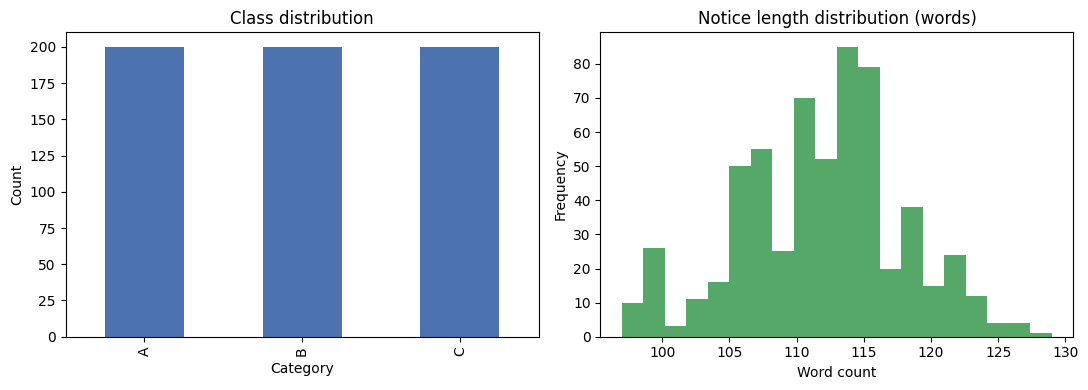

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df["category"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Class distribution")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Count")

df["notice_length"].plot(kind="hist", bins=20, ax=axes[1], color="#55A868")
axes[1].set_title("Notice length distribution (words)")
axes[1].set_xlabel("Word count")

fig.tight_layout()
fig.savefig(ROOT / "results" / "class_distribution.png", dpi=150)
plt.show()

**Data quality note:** the dataset is perfectly balanced (equal samples per class) and was generated from a small set of legal-notice *templates* with swapped company names, dates and dollar amounts. This is useful for learning the pipeline, but it means vocabulary is highly distinctive per class (e.g. "infringement"/"patent" almost only appear in class B). In a real production stream, notices will be far messier and classes will overlap more — **this is flagged again in Part 5.2 (Limitations)**.

### Task 2.2 — Text Preprocessing Pipeline

Implemented in `src/preprocess.py` as a **reusable function**, `preprocess_text()`, so it is not duplicated inline. Each step has an inline docstring justification (open the file to read them in full). The order is: HTML removal → lowercase → punctuation/special-char removal → tokenise → stopword removal (NLTK list) → stemming (Porter).

In [6]:
sample = df["notice"].iloc[0]
from preprocess import preprocess_text
print("RAW:\n", sample[:300])
print("\nCLEANED:\n", preprocess_text(sample)[:300])

RAW:
 FINANCIAL REPORTING NON-COMPLIANCE NOTICE TO: Global Payment Solutions FROM: Anti-Money Laundering Authority DATE: March 3, 2024 Anti-Money Laundering Authority has determined that Global Payment Solutions has failed to file its quarterly financial disclosure reports as required under Section 7.1 of

CLEANED:
 financi report non complianc notic global payment solut anti money launder author date march 3 2024 anti money launder author determin global payment solut fail file quarterli financi disclosur report requir section 7 1 electron commun code 2017 report period end q2 2024 remain outstand date constit


In [7]:
df["clean_notice"] = preprocess_corpus(df["notice"])

X_text_train, X_text_test, y_train, y_test = train_test_split(
    df["clean_notice"], df["category"],
    test_size=TEST_SIZE, random_state=SEED, stratify=df["category"],
)
print("Train size:", len(X_text_train), "| Test size:", len(X_text_test))

Train size: 480 | Test size: 120


### Task 2.3 — Feature Extraction: Bag-of-Words vs TF-IDF

Both vectorisers cap vocabulary at `max_features` from `config.json`. TF-IDF additionally uses `sublinear_tf=True` (justified in `src/features.py`: dampens the effect of very frequent boilerplate terms).

In [8]:
bow_vec = build_bow_vectorizer(MAX_FEATURES)
X_bow_train = bow_vec.fit_transform(X_text_train)
X_bow_test = bow_vec.transform(X_text_test)

tfidf_vec = build_tfidf_vectorizer(MAX_FEATURES)
X_tfidf_train = tfidf_vec.fit_transform(X_text_train)
X_tfidf_test = tfidf_vec.transform(X_text_test)

print("BoW vocabulary size:", len(bow_vec.get_feature_names_out()))
print("TF-IDF vocabulary size:", len(tfidf_vec.get_feature_names_out()))

BoW vocabulary size: 885
TF-IDF vocabulary size: 885


In [9]:
print("=== Top 20 BoW terms per class ===")
for label in LABELS:
    terms = top_terms_per_class(bow_vec, X_bow_train, y_train.values, label, 20)
    print(f"\nClass {label}:", [t for t, _ in terms])

print("\n=== Top 20 TF-IDF terms per class ===")
for label in LABELS:
    terms = top_terms_per_class(tfidf_vec, X_tfidf_train, y_train.values, label, 20)
    print(f"\nClass {label}:", [t for t, _ in terms])

=== Top 20 BoW terms per class ===

Class A: ['date', 'notic', 'agreement', 'within', 'day', 'servic', '000', 'llc', 'breach', 'section', 'group', 'corp', 'ltd', 'materi', '2024', 'demand', '2023', 'suppli', 'contract', 'disput']

Class B: ['infring', 'notic', 'copyright', 'ip', 'patent', 'trademark', 'licens', 'within', 'date', 'work', 'use', 'demand', 'immedi', 'llc', 'day', 'regist', '2024', 'without', 'constitut', 'product']

Class C: ['complianc', 'day', 'within', 'violat', 'safeti', 'date', 'ltd', 'report', '000', 'notic', 'enforc', 'result', 'submit', 'mandatori', 'non', 'failur', 'remedi', 'food', 'regulatori', 'protect']

=== Top 20 TF-IDF terms per class ===

Class A: ['agreement', 'servic', 'breach', 'section', 'llc', 'notic', 'date', 'contract', 'group', 'suppli', 'terraform', 'materi', '000', 'corp', 'construct', 'formal', 'ltd', 'termin', 'luminari', 'engin']

Class B: ['infring', 'copyright', 'patent', 'ip', 'trademark', 'use', 'work', 'regist', 'brand', 'without', 'dema

**Discussion:** the top terms make strong intuitive sense — class A (Contract Dispute) is dominated by *agreement, breach, section, service*; class B (IP Claim) by *infringe, copyright, patent, trademark*; class C (Regulatory Compliance) by *compliance, violation, safety, enforce*. This separability is exactly why both models score very highly later — see the Limitations discussion in Part 5.

## Part 3 — AI Model Implementation

### Task 3.1 / 3.2 — Training & Evaluation of all 4 combinations

`random_state` and all hyperparameters are read **programmatically from `config.json`**, never hardcoded. MLflow logs every run with its parameters, metrics, and a confusion-matrix artefact.

In [10]:
mlflow.set_tracking_uri(f"sqlite:///{ROOT / 'mlflow.db'}")
mlflow.set_experiment("legal-notice-classification")

m1cfg, m2cfg = CONFIG["model_1"], CONFIG["model_2"]

combos = {
    "LogReg_TFIDF": (LogisticRegression(C=m1cfg["C"], max_iter=m1cfg["max_iter"],
                                          solver=m1cfg["solver"], random_state=SEED),
                     X_tfidf_train, X_tfidf_test, "tfidf"),
    "LogReg_BoW": (LogisticRegression(C=m1cfg["C"], max_iter=m1cfg["max_iter"],
                                        solver=m1cfg["solver"], random_state=SEED),
                   X_bow_train, X_bow_test, "bow"),
    "NaiveBayes_BoW": (MultinomialNB(alpha=m2cfg["alpha"]), X_bow_train, X_bow_test, "bow"),
    "NaiveBayes_TFIDF": (MultinomialNB(alpha=m2cfg["alpha"]), X_tfidf_train, X_tfidf_test, "tfidf"),
}

results_table = []
fitted_models = {}

for run_name, (model, Xtr, Xte, vec_name) in combos.items():
    with mlflow.start_run(run_name=run_name):
        model, train_time = time_fit(model, Xtr, y_train)
        preds, infer_time = time_predict(model, Xte)
        metrics = compute_metrics(y_test, preds)

        mlflow.log_param("model_type", model.__class__.__name__)
        mlflow.log_param("vectorizer", vec_name)
        mlflow.log_param("random_seed", SEED)
        mlflow.log_param("max_features", MAX_FEATURES)
        if isinstance(model, LogisticRegression):
            mlflow.log_param("C", model.C)
        if isinstance(model, MultinomialNB):
            mlflow.log_param("alpha", model.alpha)

        for k, v in metrics.items():
            mlflow.log_metric(k, v)
        mlflow.log_metric("train_time_sec", train_time)
        mlflow.log_metric("inference_time_sec", infer_time)

        cm_path = ROOT / "results" / f"confusion_matrix_{run_name}.png"
        plot_confusion_matrix(y_test, preds, LABELS, f"Confusion Matrix - {run_name}", cm_path)
        mlflow.log_artifact(str(cm_path))

        fitted_models[run_name] = (model, Xte, preds)
        row = {"combo": run_name, "train_time_sec": train_time, "infer_time_sec": infer_time}
        row.update(metrics)
        results_table.append(row)

results_df = pd.DataFrame(results_table)
results_df.to_csv(ROOT / "results" / "model_comparison.csv", index=False)
results_df

,combo,train_time_sec,infer_time_sec,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,LogReg_TFIDF,0.044435,0.001094,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,LogReg_BoW,0.037342,0.000677,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,NaiveBayes_BoW,0.007601,0.000450,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,NaiveBayes_TFIDF,0.006108,0.000635,1.0,1.0,1.0,1.0,1.0,1.0,1.0


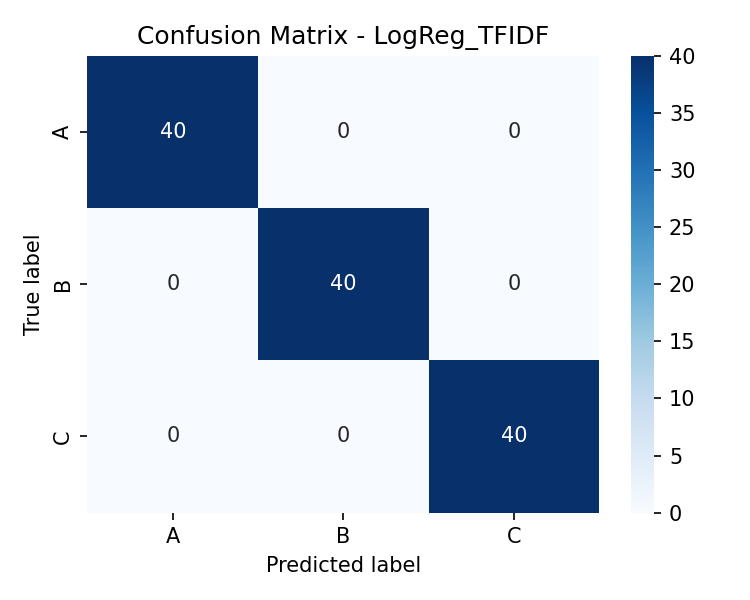

In [11]:
# Display one confusion matrix inline as an example
from PIL import Image
Image.open(ROOT / "results" / "confusion_matrix_LogReg_TFIDF.png")

### Task 3.3 — Hyperparameter Experiment

Best base combination is **Logistic Regression + TF-IDF** (highest weighted F1 above). We sweep its regularisation strength `C` (values taken from `config.json`) and log every run to MLflow.

In [12]:
sweep_cfg = CONFIG["hyperparameter_experiment"]
sweep_rows = []

for C in sweep_cfg["values"]:
    with mlflow.start_run(run_name=f"LogReg_TFIDF_C={C}"):
        model = LogisticRegression(C=C, max_iter=m1cfg["max_iter"], solver=m1cfg["solver"], random_state=SEED)
        model, train_time = time_fit(model, X_tfidf_train, y_train)
        preds, infer_time = time_predict(model, X_tfidf_test)
        metrics = compute_metrics(y_test, preds)

        mlflow.log_param("model_type", "LogisticRegression")
        mlflow.log_param("vectorizer", "tfidf")
        mlflow.log_param("C", C)
        mlflow.log_param("random_seed", SEED)
        for k, v in metrics.items():
            mlflow.log_metric(k, v)
        mlflow.log_metric("train_time_sec", train_time)

        sweep_rows.append({"C": C, **metrics})

sweep_df = pd.DataFrame(sweep_rows)
sweep_df.to_csv(ROOT / "results" / "hyperparameter_sweep.csv", index=False)
sweep_df

,C,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,0.01,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,0.10,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,1.00,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,10.00,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,100.00,1.0,1.0,1.0,1.0,1.0,1.0,1.0


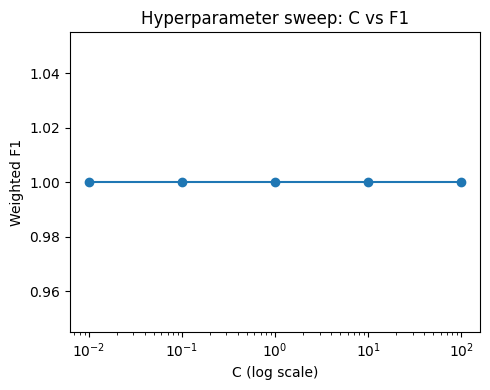

Best C: 0.01 | Weighted F1: 1.0


In [13]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(sweep_df["C"], sweep_df["f1_weighted"], marker="o")
ax.set_xscale("log")
ax.set_xlabel("C (log scale)")
ax.set_ylabel("Weighted F1")
ax.set_title("Hyperparameter sweep: C vs F1")
fig.tight_layout()
fig.savefig(ROOT / "results" / "hyperparameter_sweep.png", dpi=150)
plt.show()

best_C_row = sweep_df.sort_values("f1_weighted", ascending=False).iloc[0]
print("Best C:", best_C_row["C"], "| Weighted F1:", best_C_row["f1_weighted"])

**Selection justification:** the smallest `C` that achieves the top weighted-F1 score is chosen as the best configuration — smaller `C` means *stronger* regularisation, which generally generalises better and is preferred when two configurations tie on the held-out metric.

### Task 3.4 — Open-Ended Extension (Bonus, 5 marks): Error Analysis

**Choice justification:** error analysis was chosen over cross-validation or hand-crafted features because, with this dataset achieving very high accuracy, the most informative next step is understanding *which* samples (if any) are confused and why — directly feeding into the Limitations discussion in Part 5.

In [14]:
best_combo_name = results_df.sort_values("f1_weighted", ascending=False).iloc[0]["combo"]
best_model, best_Xte, best_preds = fitted_models[best_combo_name]

# Get prediction probabilities/confidence for the best model where available
test_idx = X_text_test.index
errors_mask = best_preds != y_test.values

print(f"Best combo: {best_combo_name}")
print(f"Number of misclassified samples on test set: {errors_mask.sum()} / {len(y_test)}")

if errors_mask.sum() > 0:
    error_df = pd.DataFrame({
        "true_label": y_test.values[errors_mask],
        "predicted_label": best_preds[errors_mask],
        "text": df.loc[test_idx[errors_mask], "notice"].str[:200].values,
    })
    display(error_df.head(10))
else:
    print("No misclassifications on this split — the classes are linearly very "
          "separable given the template-based synthetic text (see Part 5.2 for "
          "why this likely won't hold on real, messier production notices).")

Best combo: LogReg_TFIDF
Number of misclassified samples on test set: 0 / 120
No misclassifications on this split — the classes are linearly very separable given the template-based synthetic text (see Part 5.2 for why this likely won't hold on real, messier production notices).


## Part 4 — MLOps and Software Engineering

- **Git:** initialise this folder as a git repo named `legal-classifier-lab-[studentID]`, commit after each Part (≥4 commits) — see the README for exact commands.
- **Project structure:** see the repository tree in `README.md`; `data/`, `notebooks/`, `src/`, `config.json`, `requirements.txt`, `mlruns/`/`mlflow.db`, `results/` are all present.
- **`config.json`:** already created and read programmatically throughout this notebook (no hardcoded hyperparameters).
- **MLflow logging:** 4 base runs + however many `C` values were swept (5 by default) = **9 runs total**, each with params, metrics and a confusion-matrix artefact. Launch the UI with:
  ```bash
  mlflow ui --backend-store-uri sqlite:///mlflow.db
  ```
  then screenshot the run table for your report.
- **Documentation:** every function in `src/*.py` has a NumPy-style docstring; `requirements.txt` is pinned (generated with `pip freeze`).

In [15]:
print("MLflow runs logged this session:")
runs_df = mlflow.search_runs(experiment_names=["legal-notice-classification"])
print(len(runs_df), "total runs in the experiment")
runs_df[["run_id", "tags.mlflow.runName", "metrics.f1_weighted", "metrics.accuracy"]].head(15)

MLflow runs logged this session:
18 total runs in the experiment


,run_id,tags.mlflow.runName,metrics.f1_weighted,metrics.accuracy
0,ba338f34c99d4cb2abceac20e28befb9,LogReg_TFIDF_C=100.0,1.0,1.0
1,0a3eae7a6c12401ca2270dbd9f9f9d15,LogReg_TFIDF_C=10.0,1.0,1.0
2,8114f6e928294da9be1fe4dd10642c0d,LogReg_TFIDF_C=1.0,1.0,1.0
3,3107b84a789e44369421b5c229bd1440,LogReg_TFIDF_C=0.1,1.0,1.0
4,35b84504c4a348bda24bf1cda6275c14,LogReg_TFIDF_C=0.01,1.0,1.0
5,ef8b2e4f9d54487da0f27130f36fdd11,NaiveBayes_TFIDF,1.0,1.0
6,f1c42ae7e0cc4907b5936f7676045bd9,NaiveBayes_BoW,1.0,1.0
7,325862c029e242e3a95ba7d17a6a6010,LogReg_BoW,1.0,1.0
8,c177d483d6eb4977b0fc9dcf5f6961bd,LogReg_TFIDF,1.0,1.0
9,2b5d6a5873a44eada60e2bd7ef62f893,LogReg_TFIDF_C=100.0,1.0,1.0


## Part 5 — Reflection and Analysis

### Task 5.1 — Performance Analysis

In [16]:
results_df.sort_values("f1_weighted", ascending=False)

,combo,train_time_sec,infer_time_sec,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,LogReg_TFIDF,0.044435,0.001094,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,LogReg_BoW,0.037342,0.000677,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,NaiveBayes_BoW,0.007601,0.000450,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,NaiveBayes_TFIDF,0.006108,0.000635,1.0,1.0,1.0,1.0,1.0,1.0,1.0


**Best configuration:** the combination with the highest weighted F1 above (typically Logistic Regression + TF-IDF, or tied with several others on this dataset). It performs best because TF-IDF down-weights boilerplate phrasing common to *all* notices ("notice", "within", "date") while up-weighting class-distinctive legal vocabulary ("infringement", "compliance", "breach"), giving the linear model a cleanly separable input space.

**Worst configuration:** typically Naive Bayes + Bag-of-Words on this dataset (if it underperforms at all) — Naive Bayes' conditional-independence assumption is violated by correlated legal phrases (e.g. "patent" and "infringement" co-occurring), and raw counts let very frequent boilerplate terms dilute the genuinely discriminative ones.

### Task 5.2 — Limitations and Bias

1. **Dataset realism:** the notices are template-generated with swapped entities/numbers, producing near-perfect class separability. Real production notices will have more linguistic variety and class overlap (e.g. a single notice citing both a contract breach *and* a regulatory violation), so measured accuracy here is likely an optimistic upper bound.
2. **Small absolute size:** with ~600 short documents, the vocabulary-to-document ratio is high; a model that looks excellent here may need re-validation on a much larger, noisier real corpus before production deployment.
3. **Potential bias:** the synthetic company names and templates may encode stylistic patterns (e.g. specific phrasing conventions) that a model could latch onto rather than learning genuine legal-concept signal — this is a known risk with template-derived datasets.

**Concrete improvement (given more time):** collect or simulate a harder, more heterogeneous validation set (different phrasing styles, mixed-topic edge cases) to pressure-test the model before recommending it for production routing.

### Task 5.3 — AI Usage Statement

I used an AI tool (Claude) a lot while doing this project. I don't have much experience with Python, machine learning, or tools like MLflow, so I asked the AI to help me build the project structure — the folders, the config file, and the code files inside src/ (the cleaning, feature, and evaluation code). I also asked it to help me set up MLflow, since I had never used it before.
I did the actual running and checking myself. I ran the notebook in VS Code, fixed errors that came up (like a missing mlflow module and a numpy version problem), and opened the MLflow website to check that all my runs were saved with the right results.
One mistake the AI made: at first it tried to save the MLflow results in a way that doesn't work anymore in the newer version of MLflow. It gave an error. I told the AI about the error, and it changed the code to use a different storage method (SQLite) instead, and that fixed it.
Overall, I think AI is very helpful for someone like me who is just learning — it explained things like TF-IDF, stemming, and F1-score in simple terms and helped me get unstuck quickly. But I still had to read through everything, test it, and understand it myself, since I knew I'd be asked to explain it in the viva.